# Random Forest Regression

## Import Libraries

In [1]:
# Standard library imports for data handling
import pandas as pd
import numpy as np
import joblib

# Import scikit-learn tools for model selection and evaluation
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Import categorical encoders for handling make and model features
from category_encoders import BinaryEncoder

# Import visual libraries
import matplotlib.pyplot as plt
import seaborn as sns

## Load Final Dataset

In [2]:
# Define the path for the processed combined dataset
DATA_PATH = '../data/processed/combined_final_dataset.csv'

# Read the CSV file into a pandas dataframe
df = pd.read_csv(DATA_PATH)

# Output the dimensions of the loaded dataset for verification
print(f"Loaded prepared dataset: {df.shape[0]} rows x {df.shape[1]} columns")

# Display the first few records of the dataframe
df.head()

Loaded prepared dataset: 769948 rows x 11 columns


,country,make,model,year,age,mileage,transmission,fuelType,mpg,engineSize,price
0,Uk,Vauxhall,Corsa,2018,2,9876.0,Manual,Petrol,46.13158,1.4,10124.340
1,Uk,Vauxhall,Corsa,2019,1,2500.0,Manual,Petrol,45.21561,1.4,15401.580
2,Uk,Vauxhall,Corsa,2017,3,9625.0,Automatic,Petrol,39.88633,1.4,12553.668
3,Uk,Vauxhall,Corsa,2016,4,25796.0,Manual,Petrol,46.13158,1.4,10914.000
4,Uk,Vauxhall,Corsa,2019,1,3887.0,Manual,Petrol,36.22245,1.4,12840.000


## Data Preprocessing

### Handle year column, and EV mpg and engineSize

In [3]:
# Initialize random seed and test split ratio for reproducibility
RANDOM_SEED = 42
TEST_SIZE = 0.2

# Identify and drop rows with missing or invalid target values
df = df.dropna(subset=['price'])
df = df[df['price'] > 0]

# Output the new dataset shape after target filtering
print(f"Dataset after filtering: {df.shape}")

# Drop the year column to prevent multicollinearity with the age feature
if 'year' in df.columns:
    df = df.drop(columns=['year'])
    print("Dropped 'year' column")

# Create a binary is_ev flag to identify electric vehicles for special handling
df['is_ev'] = (df['fuelType'] == 'Electric').astype(int)

# Output the frequency and percentage of EV records in the dataset
print(f"EV records: {df['is_ev'].sum()} / {len(df)} ({df['is_ev'].mean()*100:.2f}%)")

# Calculate global medians for MPG and engine size from non-electric vehicles
non_ev_mpg_median = df.loc[df['is_ev'] == 0, 'mpg'].median()
non_ev_engine_median = df.loc[df['is_ev'] == 0, 'engineSize'].median()

# Impute electric vehicle MPG values with the calculated non-EV median
df.loc[df['is_ev'] == 1, 'mpg'] = non_ev_mpg_median

# Impute electric vehicle engine size values with the calculated non-EV median
df.loc[df['is_ev'] == 1, 'engineSize'] = non_ev_engine_median

# Output the imputation values used for the EV records
print(f"Imputed EV mpg with {non_ev_mpg_median:.1f}, engineSize with {non_ev_engine_median:.1f}")

Dataset after filtering: (769948, 11)
Dropped 'year' column
EV records: 15854 / 769948 (2.06%)
Imputed EV mpg with 25.5, engineSize with 2.4


### Set train/test split

In [4]:
# Define the target variable for the regression problem
TARGET = 'price'

# Separate the feature matrix (X) from the target vector (y)
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Perform a stratified split to ensure consistent EV representation across sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED,
    stratify=X['is_ev']
)

# Output the number of samples in the training and testing partitions
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:      {X_test.shape[0]} samples")

# Calculate sample weights to prioritize UK market accuracy in the model
train_weights = np.where(X_train['country'] == 'UK', 4.0, 0.5)

# Output confirmation of sample weight assignment
print("\nSample weights computed (UK=4.0, US=0.5).")

Training set: 615958 samples
Test set:      153990 samples

Sample weights computed (UK=4.0, US=0.5).


### Encoding Categorical Features

#### One-Hot Encode Low Cardinality Features

In [5]:
# Define categorical features with low cardinality for one-hot encoding
low_cat_features = ['country', 'transmission', 'fuelType']

# Convert categorical variables into dummy features for the training set
X_train = pd.get_dummies(X_train, columns=low_cat_features, drop_first=True)

# Convert categorical variables into dummy features for the test set
X_test = pd.get_dummies(X_test, columns=low_cat_features, drop_first=True)

# Align the train and test dataframes to ensure matching column structures
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Extract and store the final feature names for the deployment bundle
features = list(X_train.columns)

#### Target Encode High Cardinality Features

In [6]:
# Identify high-cardinality features for target encoding
high_cat_features = ['make', 'model']

# Initialize the ColumnTransformer to handle target encoding for specified features
preprocessor = ColumnTransformer(
    transformers=[
        ('binary_enc', BinaryEncoder(), high_cat_features),
    ],
    remainder='passthrough'
)

# Construct the full modeling pipeline including preprocessing and scaling
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1))
])

## Overfit Test

In [7]:
# Define a range of depths to evaluate the bias-variance tradeoff
depth_values = [5, 10, 15, 20, 25, None]
depth_results = []

print("Analyzing R² sensitivity to tree depth...")

for depth in depth_values:
    # Update the pipeline's regressor depth parameter
    pipeline.set_params(regressor__max_depth=depth)
    
    # Fit the model using sample weights to maintain consistency with your UK-priority logic
    pipeline.fit(X_train, y_train, regressor__sample_weight=train_weights)
    
    # Calculate R-squared scores for both partitions
    train_score = pipeline.score(X_train, y_train)
    test_score = pipeline.score(X_test, y_test)
    
    depth_results.append({
        'Max Depth': 'None' if depth is None else depth,
        'Train R2': train_score,
        'Test R2': test_score,
        'Difference': train_score - test_score
    })
    
    print(f"Depth: {depth if depth else 'None':<4} | Train R²: {train_score:.4f} | Test R²: {test_score:.4f} | Diff: {train_score - test_score:.4f}")

# Convert findings into a summary dataframe for clear comparison
depth_df = pd.DataFrame(depth_results).set_index('Max Depth')
print("\n=== Tree Depth Comparison Summary ===")
print(depth_df)

Analyzing R² sensitivity to tree depth...


KeyboardInterrupt: 

## Hyperparameter Tuning

In [8]:
# Define the search space for Random Forest hyperparameter optimization
param_distributions = {
    'regressor__n_estimators': [100, 200, 300],          
    'regressor__max_depth': [10, 15, 20, None],          
    'regressor__max_features': ['sqrt', 'log2', 1.0]
}

# Initialize RandomizedSearchCV to find the optimal model configuration
model_random = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=5, 
    cv=5,      
    scoring='neg_mean_absolute_error',
    verbose=2,
    random_state=RANDOM_SEED,
    n_jobs=2
)

# Output progress message before starting the search process
print("Starting Hyperparameter Tuning... This may take a few minutes.")

# Execute the search using the calculated sample weights for training
model_random.fit(X_train, y_train, regressor__sample_weight=train_weights)

# Extract the best estimator found during the search process
best_pipeline = model_random.best_estimator_

# Output the best hyperparameter combination to the console
print("\n=== Best Hyperparameters Found ===")
print(model_random.best_params_)

Starting Hyperparameter Tuning... This may take a few minutes.
Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END regressor__max_depth=None, regressor__max_features=1.0, regressor__n_estimators=300; total time= 7.0min
[CV] END regressor__max_depth=None, regressor__max_features=1.0, regressor__n_estimators=300; total time= 7.0min
[CV] END regressor__max_depth=None, regressor__max_features=1.0, regressor__n_estimators=300; total time= 7.0min
[CV] END regressor__max_depth=None, regressor__max_features=1.0, regressor__n_estimators=300; total time= 7.0min
[CV] END regressor__max_depth=15, regressor__max_features=log2, regressor__n_estimators=200; total time=  51.1s


/Users/karimamr/miniconda3/envs/usedCars/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END regressor__max_depth=15, regressor__max_features=log2, regressor__n_estimators=200; total time=  54.4s
[CV] END regressor__max_depth=15, regressor__max_features=log2, regressor__n_estimators=200; total time=  54.0s
[CV] END regressor__max_depth=15, regressor__max_features=log2, regressor__n_estimators=200; total time=  53.9s
[CV] END regressor__max_depth=15, regressor__max_features=log2, regressor__n_estimators=200; total time=  54.6s
[CV] END regressor__max_depth=None, regressor__max_features=1.0, regressor__n_estimators=300; total time= 6.8min
[CV] END regressor__max_depth=20, regressor__max_features=1.0, regressor__n_estimators=300; total time= 6.5min
[CV] END regressor__max_depth=20, regressor__max_features=1.0, regressor__n_estimators=300; total time= 6.6min
[CV] END regressor__max_depth=20, regressor__max_features=1.0, regressor__n_estimators=300; total time= 6.8min
[CV] END regressor__max_depth=20, regressor__max_features=1.0, regressor__n_estimators=300; total time= 7.

### Model Assessment

#### Check for overfitting

In [9]:
# Generate predictions on the training data to assess memorization
y_train_pred = best_pipeline.predict(X_train)

# Calculate the R-squared score for the training set
train_r2 = r2_score(y_train, y_train_pred)

# Generate predictions on the unseen test data to assess generalization
y_test_pred = best_pipeline.predict(X_test)

# Calculate the R-squared score for the testing set
test_r2 = r2_score(y_test, y_test_pred)

# Output the overfitting audit results for comparison
print("Overfitting Checker")
print(f"Training R²: {train_r2:.4f}")
print(f"Testing R²:  {test_r2:.4f}")
print(f"Difference:  {(train_r2 - test_r2):.4f}")

Overfitting Checker
Training R²: 0.9820
Testing R²:  0.9502
Difference:  0.0318


#### R2, MAE, MAPE and RMSE

In [10]:
# Generate final predictions on the raw test set using the tuned pipeline
y_pred = best_pipeline.predict(X_test)

# Calculate Mean Absolute Error (MAE) in currency units
mae = mean_absolute_error(y_test, y_pred)

# Calculate Mean Absolute Percentage Error (MAPE) for error scale context
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

# Calculate Root Mean Squared Error (RMSE) to penalize larger errors
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate the final R-squared score for the predictive model
r2 = r2_score(y_test, y_pred)

# Output the final performance summary to the console
print("\n=== Tuned Pipeline Performance ===")
print(f"MAE:  ${mae:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"RMSE: ${rmse:.2f}")
print(f"R²:   {r2:.4f}")


=== Tuned Pipeline Performance ===
MAE:  $1954.54
MAPE: 8.69%
RMSE: $2911.60
R²:   0.9502


#### Feature Importance Plot

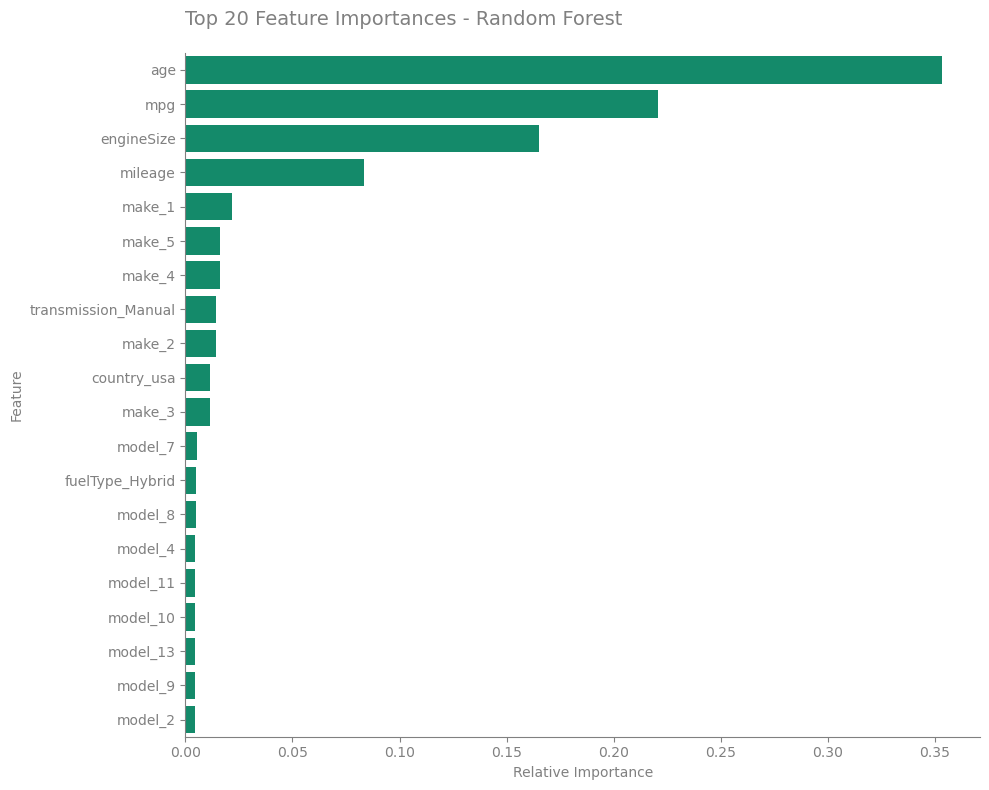

In [12]:
# Extract the trained random forest model from the pipeline
rf_model = best_pipeline.named_steps['regressor']
grey_colour = '#808080'

# Get feature importances array
importances = rf_model.feature_importances_

# Extract feature names from the preprocessor to match the importances
try:
    # get_feature_names_out() works for scikit-learn >= 1.0
    feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
    # Clean up names by removing pipeline prefixes (e.g., 'remainder__')
    feature_names = [name.split('__')[-1] for name in feature_names]
except AttributeError:
    # Fallback in case of older library versions
    feature_names = [f"Feature {i}" for i in range(len(importances))]

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 20 most important features
plt.figure(figsize=(10, 8))
ax = sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', color='#009E73')
plt.title('Top 20 Feature Importances - Random Forest', 
          loc='left', 
          color='grey', 
          fontsize=14, 
          pad=20)

ax.spines['left'].set_color(grey_colour)
ax.spines['bottom'].set_color(grey_colour)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='both', colors=grey_colour)
ax.xaxis.label.set_color(grey_colour)
ax.yaxis.label.set_color(grey_colour)

plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../graphs/random_forest_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

#### Residual Plots

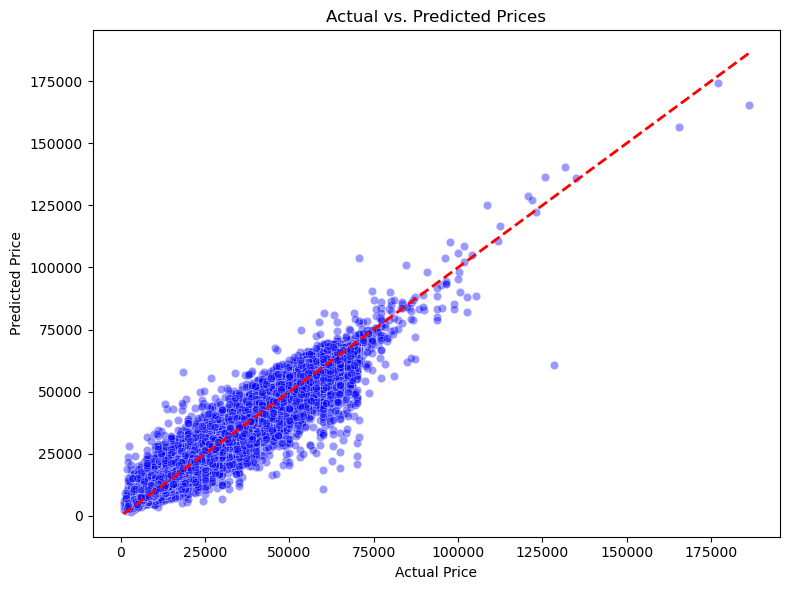

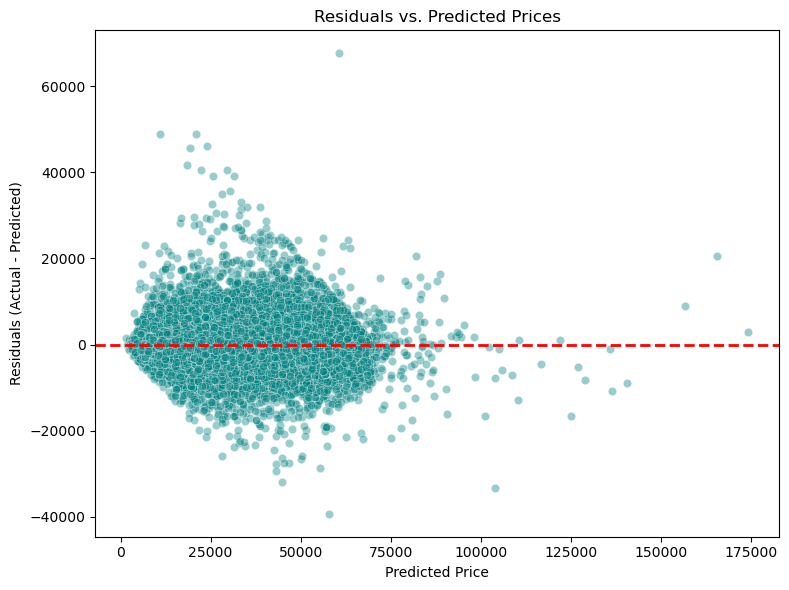

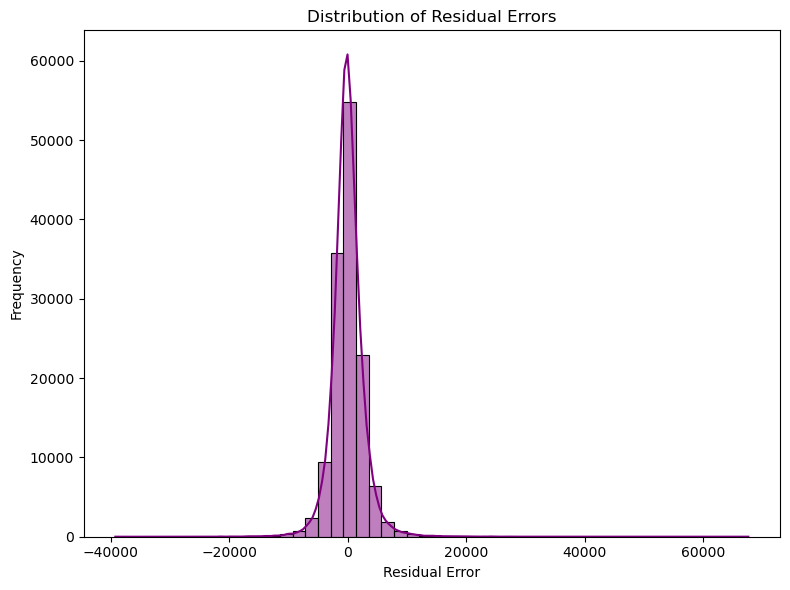

In [ ]:
# Calculate the residuals (errors)
residuals = y_test - y_pred

# --- Plot 1: Actual vs. Predicted ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color='blue')
# Add a perfect prediction line (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.tight_layout()
plt.savefig('../graphs/actual_vs_predicted.png', dpi=300)
plt.show()

# --- Plot 2: Residuals vs. Predicted ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.4, color='teal')
# Add a horizontal line at 0 for reference
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Residuals vs. Predicted Prices')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.tight_layout()
plt.savefig('../graphs/residuals_vs_predicted.png', dpi=300)
plt.show()

# --- Plot 3: Distribution of Residuals ---
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=50, color='purple')
plt.title('Distribution of Residual Errors')
plt.xlabel('Residual Error')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../graphs/distribution_of_residuals.png', dpi=300)
plt.show()

#### Model Export

In [ ]:
# Initialize the deployment bundle including the pipeline and metadata
deployment_bundle = {
    "pipeline": best_pipeline,
    "non_ev_mpg_median": non_ev_mpg_median,
    "non_ev_engine_median": non_ev_engine_median,
    "feature_columns": list(X_train.columns) 
}

# Define the final export path for the model pickle file
EXPORT_PATH = '../models/model.pkl'

# Save the deployment bundle to the specified directory using joblib
joblib.dump(deployment_bundle, EXPORT_PATH)

# Output confirmation of the successful model export
print(f"\nSuccess! Deployment bundle saved to: {EXPORT_PATH}")


Success! Deployment bundle saved to: ../models/model.pkl
